# Exercise 11 - LLM Auditing
_By Abigail Hayes_

In this exercise we will look at auditing LLMs. We will specifically look at methods for examining training data and the influence of the prompt on the model output.

**You will likely need to run this notebook on the BWUniCluster3.0 or on Google Colab to have enough GPU memory and compute.**

This exercise consists of two parts:
1. Examining training data
2. Evaluating the inflence of the prompt

## Setup

Follow the instructions from Exercise 3 for LLM setup. Make sure the correct kernel is selected for this notebook.

You will need to install some new modules into your environment:

``source ENV_NAME/bin/activate``

``pip install captum``

``pip install bitsandbytes``

``pip install accelerate``


## Training data

LLMs are trained with huge quantities of training data. It will all have some level of impact on the parameters the model learns and therefore on the model outputs. But can we work in the opposite direction and see which texts have directly contributed to the model output?

[OLMoTrace](https://aclanthology.org/2025.acl-demo.18/) has been developed to do exactly this task. From the output of a model, it will search through the training data for exact n-gram matches.

You can access a version of their setup in this [playground](https://playground.allenai.org/). Let's have a first look together...

In their paper, the creators give three specific use cases that they have identified:
- Fact checking
- Tracing "creative" expressions
- Tracing math capabilities

We can test each of these ourselves with examples.

### Fact checking

Within the interface, ask the following questions. Use the linked documents to determine whether you think the responses are correct.

1. Who is the rector of the University of Mannheim?
2. Which country has won the most FIFA football world cups?
3. Where was the birthplace of the Industrial Revolution?

Which questions had matches with relevant documents? Which questions seem to have been answered correctly? How could we do this more systematically?

### Tracing creative expressions

Ask the model to 'Write a short story of 3 paragraphs in the style of AN AUTHOR.'

What type of documents are the traced documents? Is the generated response in the style of the specified author? How creative do you now think the output is?

### Tracing math capabilities

Ask the model the following question from AIME I 2024 Question 3:

Alice and Bob play the following game. A stack of n tokens lies before them. The players take turns with Alice going first. On each turn, the player removes either 1 token or 4 tokens from the stack. Whoever removes the last token wins. Find the number of positive integers n less than or equal 2024 to for which there exists a strategy for Bob that guarantees that Bob will win the game regardless of Alice's play.

Does it seem like the model has seen this question in training? How closely related are the problems it is transferring knowledge from?

## Prompt influence

Here we will use a tool that we can access programatically called Captum to look at the influence of prompts. The following code is based on the [captum.ai tutorial](https://captum.ai/tutorials/Llama2_LLM_Attribution).

We begin by setting up some basic functions that let us access the model.

In [1]:
import warnings

import bitsandbytes as bnb
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

from captum.attr import (
    FeatureAblation, 
    ShapleyValues,
    LayerIntegratedGradients, 
    LLMAttribution, 
    LLMGradientAttribution, 
    TextTokenInput, 
    TextTemplateInput,
    ProductBaselines,
)

# Ignore warnings due to transformers library
warnings.filterwarnings("ignore", ".*past_key_values.*")
warnings.filterwarnings("ignore", ".*Skipping this token.*")

In [14]:
def load_model(model_name, bnb_config):
    n_gpus = torch.cuda.device_count()
    max_memory = "10000MB"

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",  # dispatch efficiently the model on the available ressources
        max_memory = {i: max_memory for i in range(n_gpus)},
    )
    tokenizer = AutoTokenizer.from_pretrained(model_name, token=True)

    # Needed for LLaMA tokenizer
    #tokenizer.pad_token = tokenizer.eos_token

    return model, tokenizer

def create_bnb_config():
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
    )

    return bnb_config

model_name = "allenai/OLMo-2-0425-1B-Instruct" 

bnb_config = create_bnb_config()

model, tokenizer = load_model(model_name, bnb_config)

Now we will test the model with a simple prompt.

In [15]:
eval_prompt = "Dave lives in Palm Coast, FL and is a lawyer. His personal interests include"

model_input = tokenizer(eval_prompt, return_tensors="pt").to("cuda")
model.eval()
with torch.no_grad():
    output_ids = model.generate(model_input["input_ids"], max_new_tokens=15)[0]
    response = tokenizer.decode(output_ids, skip_special_tokens=True)
    print(response)

Dave lives in Palm Coast, FL and is a lawyer. His personal interests include reading, hiking, and playing guitar. He enjoys spending time with his family


It is working so now we can look at the different evaluation options.

### Pertubation-based attribution

We first begin with ``FeatureAblatation`` which evaluates the effect of removing each of the features from the input string to see how it affects the predicted probability of the target string. We will start with each token as a feature.

In [16]:
fa = FeatureAblation(model)

llm_attr = LLMAttribution(fa, tokenizer)

skip_tokens = [1]  # skip the special token for the start of the text <s>
inp = TextTokenInput(
    eval_prompt, 
    tokenizer,
    skip_tokens=skip_tokens,
)

target = "reading, hiking, and playing guitar."

attr_res = llm_attr.attribute(inp, target=target, skip_tokens=skip_tokens)

print("attr to the output sequence:", attr_res.seq_attr.shape)  # shape(n_input_token)
print("attr to the output tokens:", attr_res.token_attr.shape)  # shape(n_output_token, n_input_token)

attr to the output sequence: torch.Size([16])
attr to the output tokens: torch.Size([8, 16])


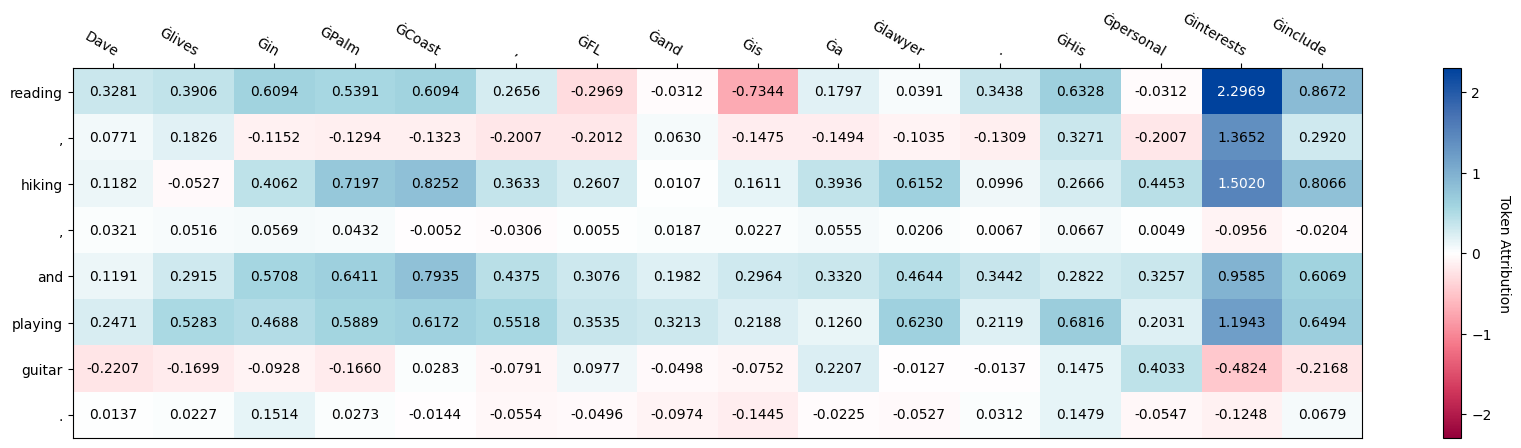

In [17]:
attr_res.plot_token_attr(show=True)

There seems to be too much going on when we go from a token level. Let's try with just some important values.

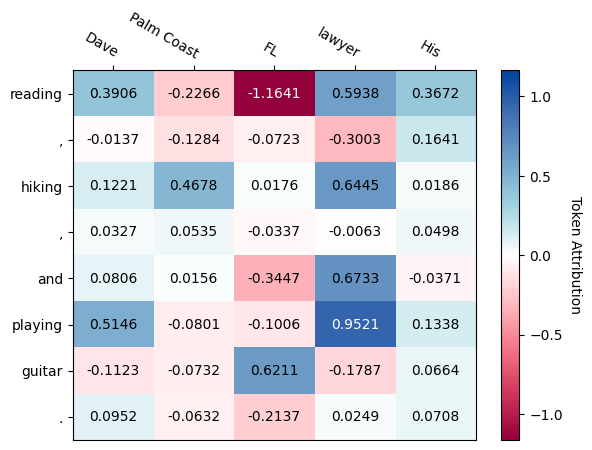

In [18]:
inp = TextTemplateInput(
    template="{} lives in {}, {} and is a {}. {} personal interests include", 
    values=["Dave", "Palm Coast", "FL", "lawyer", "His"],
)

target = "reading, hiking, and playing guitar."

attr_res = llm_attr.attribute(inp, target=target, skip_tokens=skip_tokens)

attr_res.plot_token_attr(show=True)

With this particular setup, when the feature is removed for ablation, it is replaced by an empty string. To keep this comparison more relevant, we can specifically define a baseline to use instead.

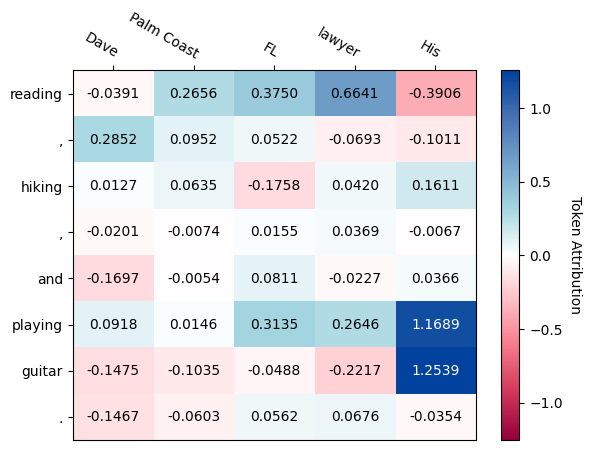

In [19]:
inp = TextTemplateInput(
    template="{} lives in {}, {} and is a {}. {} personal interests include", 
    values=["Dave", "Palm Coast", "FL", "lawyer", "His"],
    baselines=["Sarah", "Seattle", "WA", "doctor", "Her"],
)

attr_res = llm_attr.attribute(inp, target=target, skip_tokens=skip_tokens)

attr_res.plot_token_attr(show=True)

We can even set up a more sophisticated baseline which has multiple options and samples across multiple runs. Additionally, masks are used to associate some of the features i.e. the city and state.

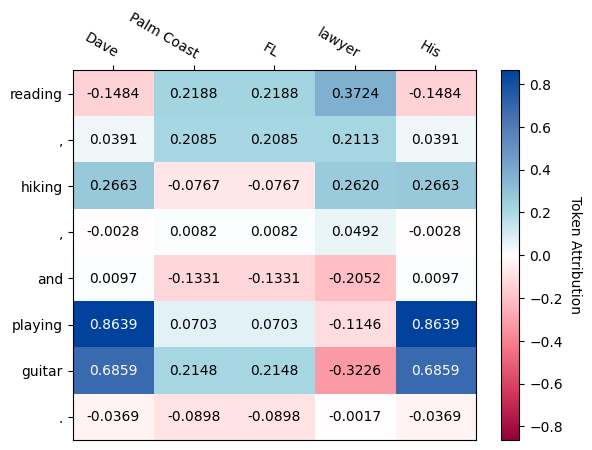

In [20]:
baselines = ProductBaselines(
    {
        ("name", "pronoun"):[("Sarah", "her"), ("John", "His"), ("Martin", "His"), ("Rachel", "Her")],
        ("city", "state"): [("Seattle", "WA"), ("Boston", "MA")],
        "occupation": ["doctor", "engineer", "teacher", "technician", "plumber"], 
    }
)

inp = TextTemplateInput(
    "{name} lives in {city}, {state} and is a {occupation}. {pronoun} personal interests include", 
    values={"name": "Dave", "city": "Palm Coast", "state": "FL", "occupation": "lawyer", "pronoun": "His"}, 
    baselines=baselines,
    mask={"name": 0, "city": 1, "state": 1, "occupation": 2, "pronoun": 0},
)

attr_res = llm_attr.attribute(inp, target=target, skip_tokens=skip_tokens, num_trials=3)

attr_res.plot_token_attr(show=True)

### Gradient-based ablation

Now we move to a different approach to ablation. We will get an importance score for each input feature relative to the output. It does this by estimating an integral of the gradients.

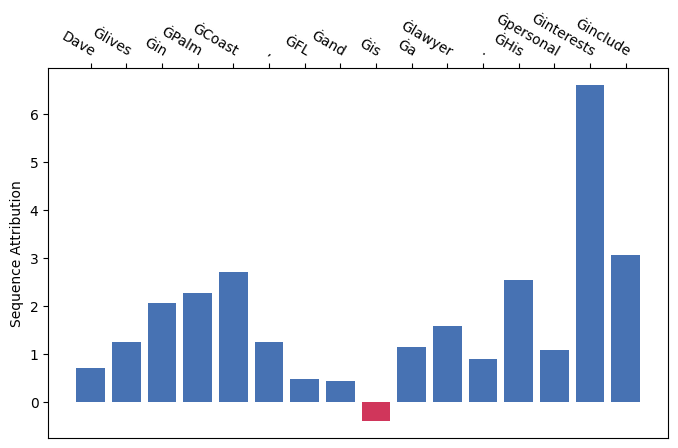

In [21]:
inp = TextTokenInput(
    eval_prompt,
    tokenizer,
    skip_tokens=skip_tokens,
)

attr_res = llm_attr.attribute(inp, target=target, skip_tokens=skip_tokens)

attr_res.plot_seq_attr(show=True)

### Task

Define your own sentence for the model to complete, together with suitable baselines. Try to include one feature which you would expect to have a large impact and one which you would expect to have no impact.

- Do the features cause the expected behaviour?
- Are there any words in the prompt that have surprisingly high/low influence?